In [1]:
!python --version

Python 3.14.0


The system cannot find the path specified.


In [2]:
from math import gamma

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cbook
from PIL import Image
from scipy.stats import multivariate_normal, norm
import networkx as nx
import torch
from torch.nn import Conv2d
from torch.nn.utils import parameters_to_vector

In [4]:
with open(r"../root.jpeg", mode="rb") as fp:
    root = np.array(Image.open(fp), dtype=np.uint8)

In [5]:
image_h, image_w, _ = np.array(root.shape) // 300

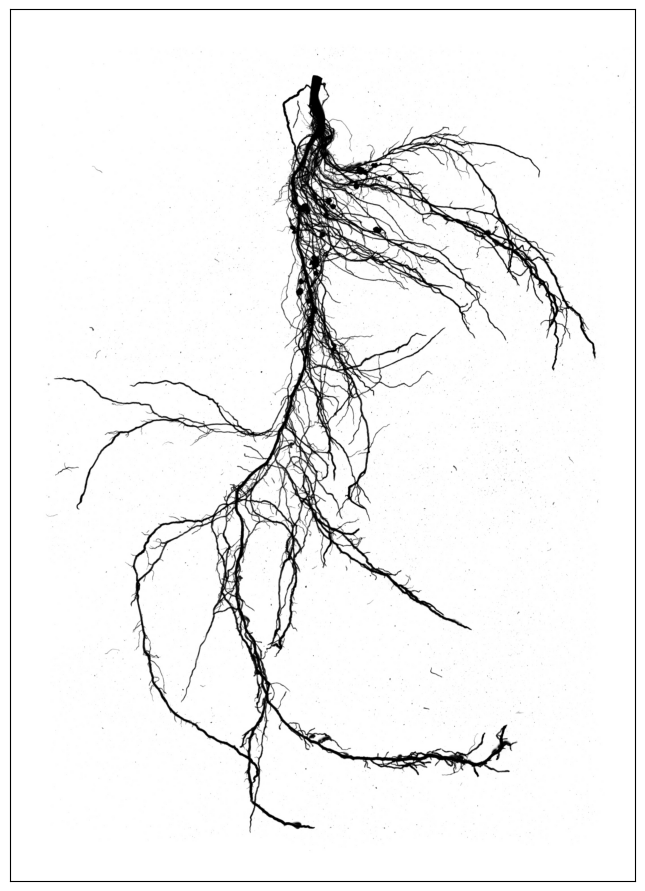

In [6]:
fig, axes = plt.subplots()
fig.set_size_inches(image_w, image_h)
axes.imshow(root)
plt.tight_layout()
axes.set_xticks([])
axes.set_yticks([])
plt.show()

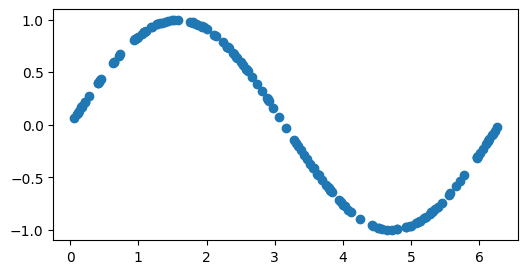

In [7]:
# create a ring of jittered dots

fig, axes = plt.subplots()
fig.set_size_inches(6, 3)

x = np.random.rand(150) * 2 * np.pi
y = np.sin(x) #+ np.random.rand(100)
axes.scatter(x, y)
plt.show()

In [8]:
x.max()

np.float64(6.262543403196283)

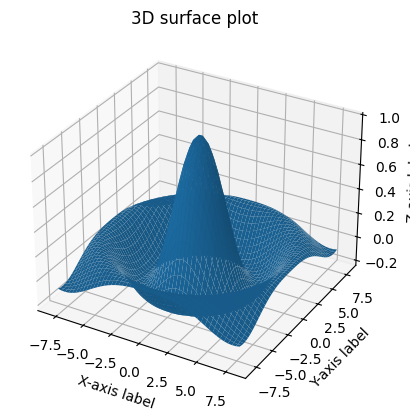

In [11]:
# Sample data
X, Y = np.meshgrid(np.linspace(-8, 8), 
                   np.linspace(-8, 8))
R = np.sqrt(X**2 + Y**2)
Z = np.sin(R) / R

fig = plt.figure()
ax = fig.add_subplot(projection = '3d')

# 3D surface plot
ax.plot_surface(X, Y, Z)

# Axis labels
ax.set_xlabel('X-axis label')
ax.set_ylabel('Y-axis label')
ax.set_zlabel('Z-axis label')

# Title
plt.title("3D surface plot")
plt.show()

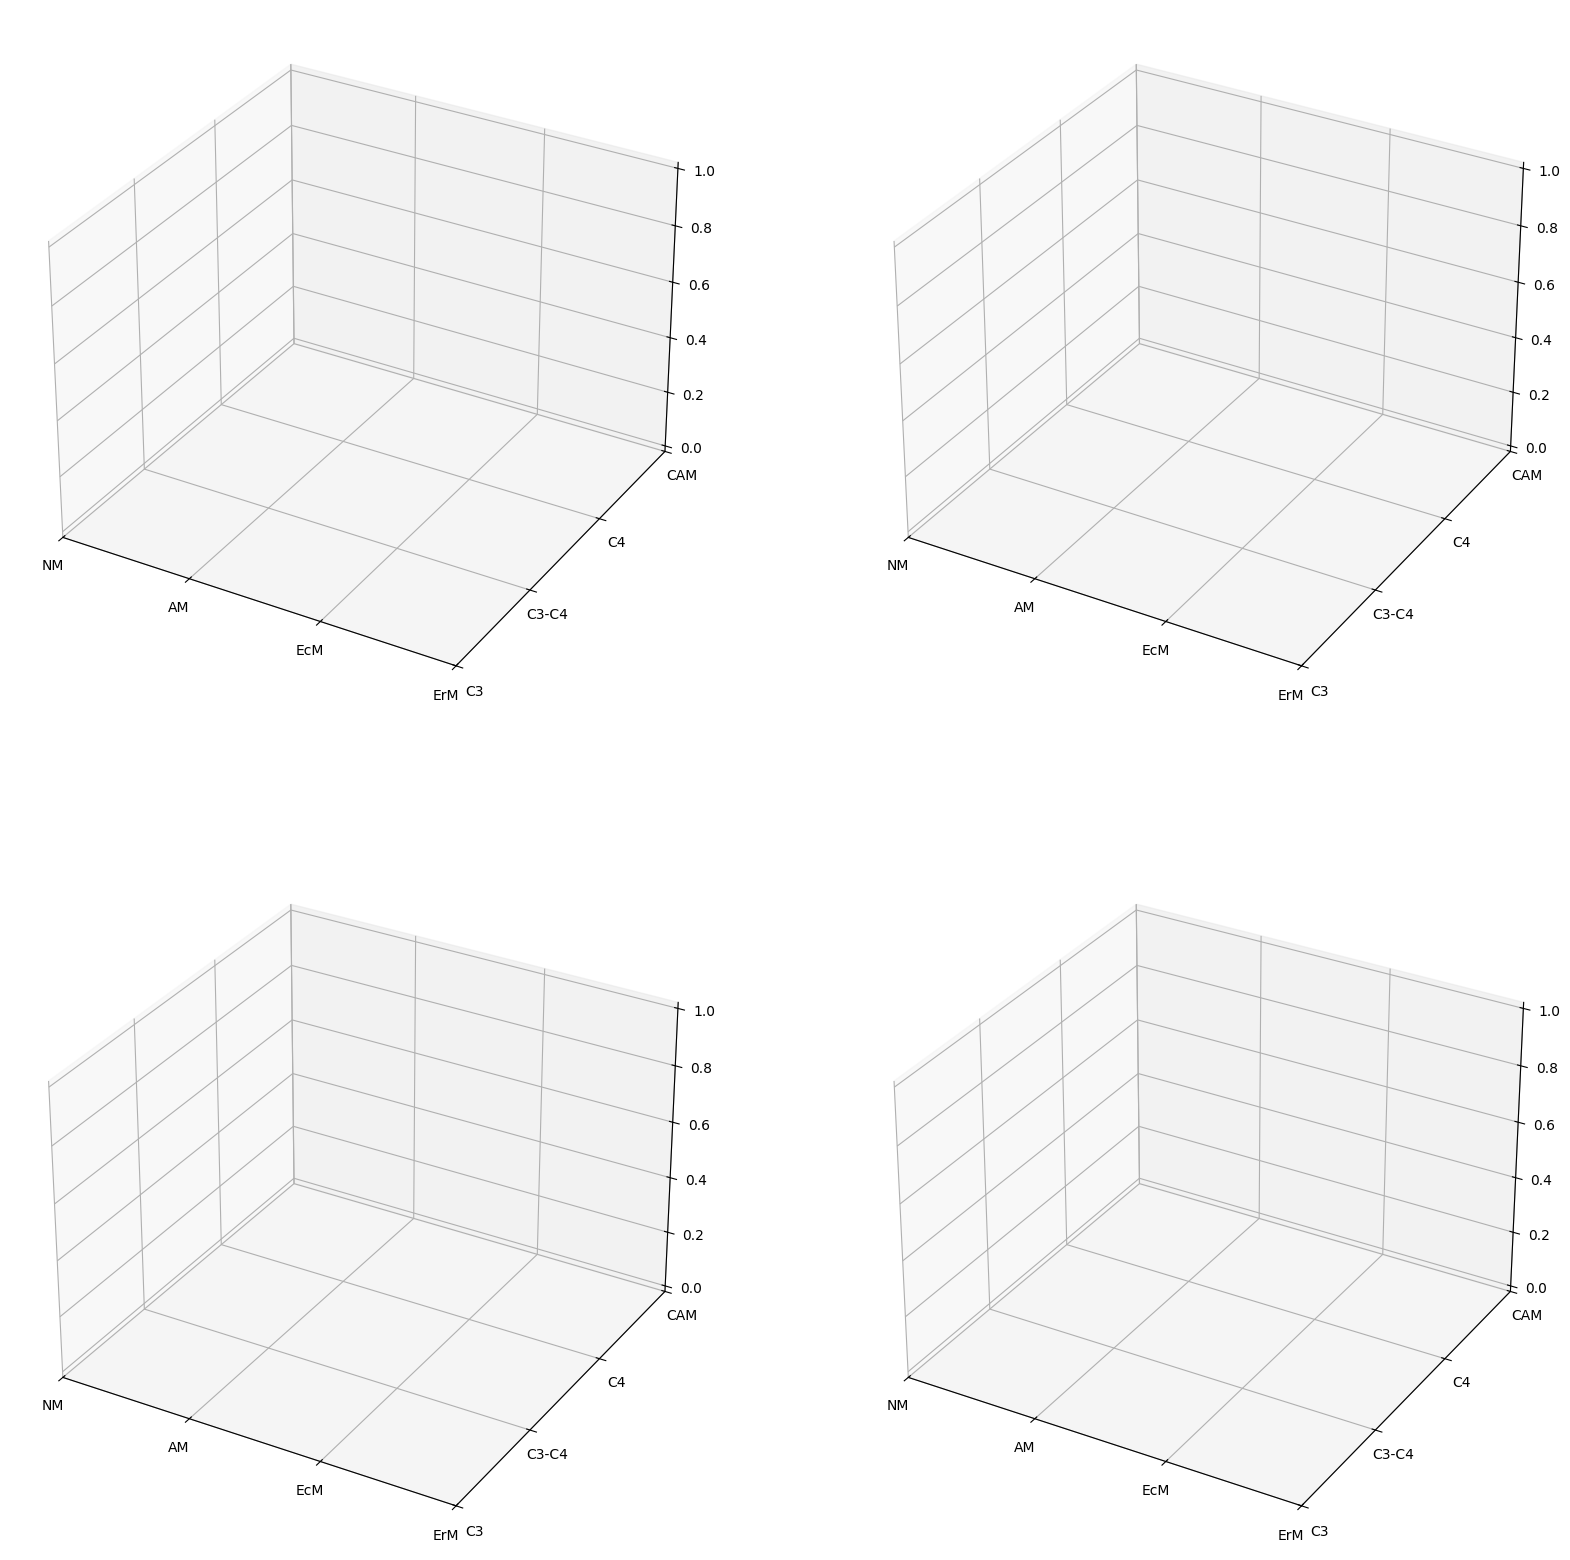

In [12]:
fig, axes = plt.subplots(nrows=2, ncols=2, subplot_kw={"projection":"3d"}) # , sharex=True, sharey=True)
fig.set_size_inches(20, 20)

for ax in axes.flatten():
    ax.set_xticks(ticks=np.linspace(ax.get_xlim()[0], ax.get_xlim()[1], num=4), labels=("NM", "AM", "EcM", "ErM"))
    ax.set_yticks(ticks=np.linspace(ax.get_ylim()[0], ax.get_ylim()[1], num=4), labels=("C3", "C3-C4", "C4", "CAM"))

# plt.tight_layout()
plt.show()

In [15]:
# https://likegeeks.com/3d-probability-plots-python/

def distribution1(x, y):
    return multivariate_normal([0, 0], [[1, 0], [0, 1]]).pdf(np.dstack((x, y)))
    
def distribution2(x, y):
    return multivariate_normal([2, 2], [[1.5, 0.5], [0.5, 1.5]]).pdf(np.dstack((x, y)))
    
x = np.linspace(-4, 6, 100)
y = np.linspace(-4, 6, 100)
X, Y = np.meshgrid(x, y)
Z1 = distribution1(X, Y)
Z2 = distribution2(X, Y)

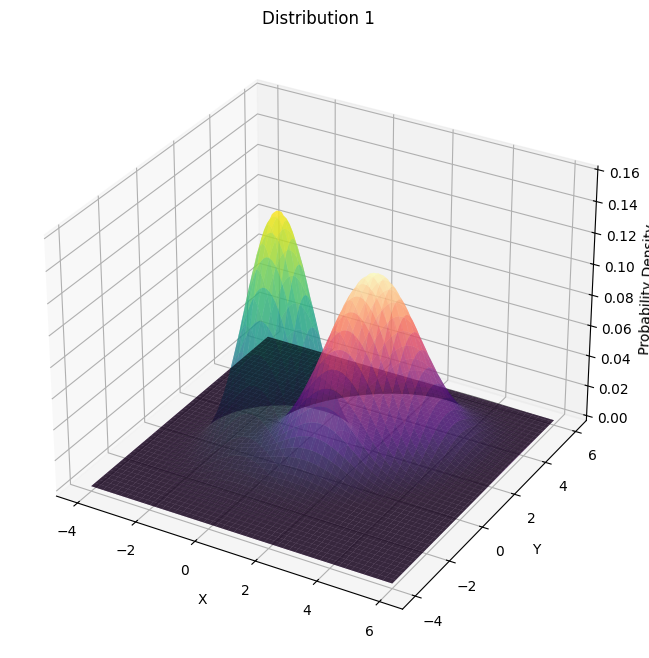

In [20]:
fig, axes = plt.subplots(subplot_kw={"projection": "3d"})
fig.set_size_inches(8, 8)
axes.plot_surface(X, Y, Z1, cmap='viridis', alpha=0.6)
axes.plot_surface(X, Y, Z2, cmap='magma', alpha=0.6)
axes.set_xlabel('X')
axes.set_ylabel('Y')
axes.set_zlabel('Probability Density')
axes.set_title('Distribution 1')

# plt.tight_layout()
plt.show()

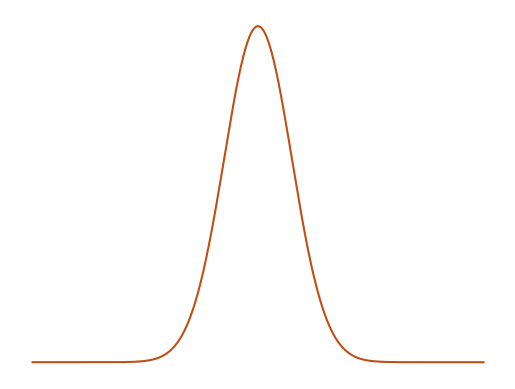

In [15]:
fig, axes = plt.subplots()
axes.set_axis_off()
x = np.linspace(0, 2, 1000)
y = norm.pdf(x, loc=1, scale=0.15)

for c in ("#C04F15", "#FFC000", "#00B050", "#00B0F0"):
    axes.plot(x, y, color=c)
    # plt.savefig(f"../plots/bell_{c}.png", format=r"png", dpi=1000, transparent=True)
    plt.show()

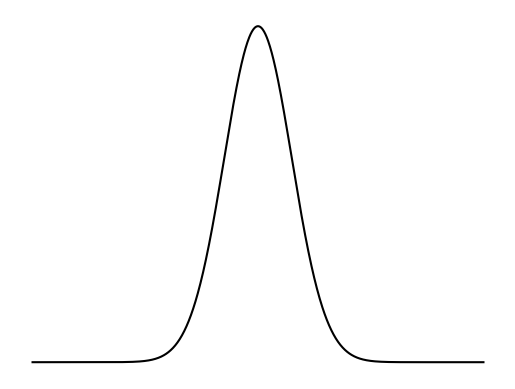

In [16]:
fig, axes = plt.subplots()
axes.set_axis_off()
x = np.linspace(0, 2, 1000)
y = norm.pdf(x, loc=1, scale=0.15)
axes.plot(x, y, color="black")
# plt.savefig(f"../plots/bellcurve.png", format=r"png", dpi=1000, transparent=True)
plt.show()

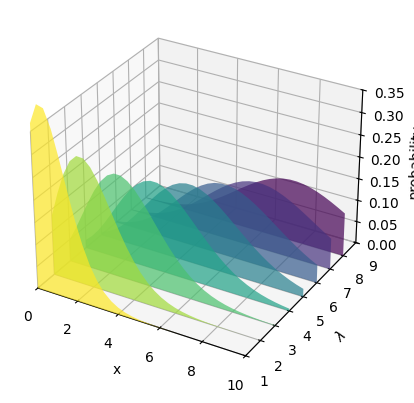

In [17]:
_gamma_v = np.vectorize(gamma)
N = 31
x = np.linspace(0., 10., N)
lambdas = range(1, 9)

ax = plt.figure().add_subplot(projection='3d')

facecolors = plt.colormaps['viridis_r'](np.linspace(0, 1, len(lambdas)))

for i, l in enumerate(lambdas):
    # Note fill_between can take coordinates as length N vectors, or scalars
    ax.fill_between(x, l, l**x * np.exp(-l) / _gamma_v(x + 1),
                    x, l, 0,
                    facecolors=facecolors[i], alpha=.7)

ax.set(xlim=(0, 10), ylim=(1, 9), zlim=(0, 0.35),
       xlabel='x', ylabel=r'$\lambda$', zlabel='probability')

plt.show()

array([ 0.,  1.,  2.,  3.,  4.,  5.,  6.,  7.,  8.,  9., 10.])

C:\Program Files\Python314\Lib\site-packages\mpl_toolkits\mplot3d\art3d.py:1328: RuntimeWarning: divide by zero encountered in divide
  vs = vs / np.linalg.norm(vs, axis=1)[:, np.newaxis]
C:\Program Files\Python314\Lib\site-packages\mpl_toolkits\mplot3d\art3d.py:1328: RuntimeWarning: invalid value encountered in divide
  vs = vs / np.linalg.norm(vs, axis=1)[:, np.newaxis]
C:\Program Files\Python314\Lib\site-packages\numpy\_core\numeric.py:1753: RuntimeWarning: invalid value encountered in multiply
  multiply(a1, b2, out=cp0)
C:\Program Files\Python314\Lib\site-packages\mpl_toolkits\mplot3d\art3d.py:1403: RuntimeWarning: divide by zero encountered in divide
  shade = ((normals / np.linalg.norm(normals, axis=1, keepdims=True))


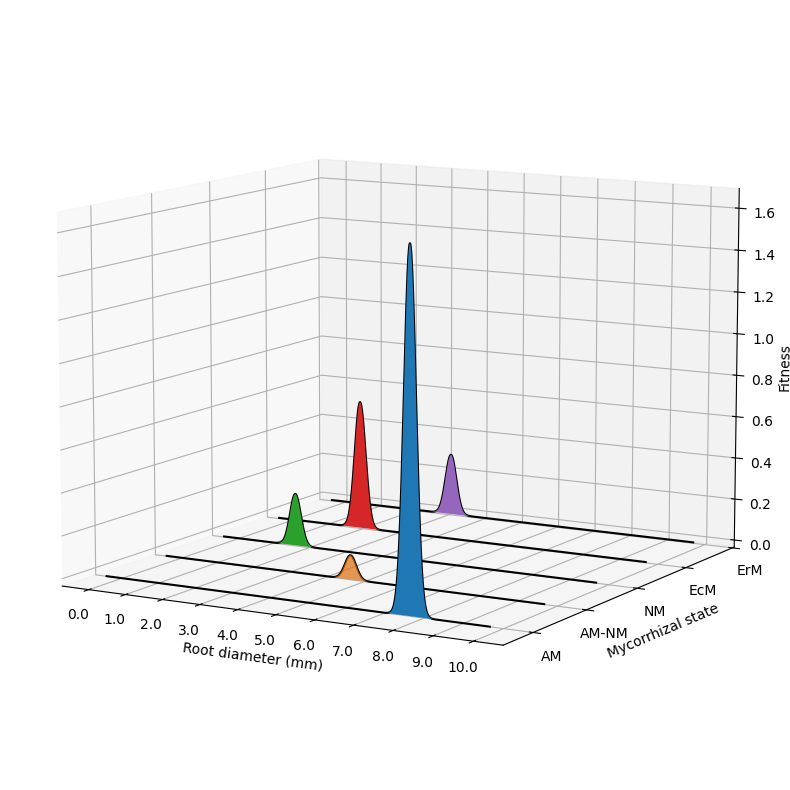

In [35]:
fig, axes = plt.subplots(subplot_kw={"projection": "3d"})
fig.set_size_inches(10, 10)

x_axis_ticks = np.linspace(start=0, stop=10, num=11)
y_axis_ticks = np.linspace(start=1, stop=9, num=5)

_x = np.linspace(start=0, stop=10, num=1000)
x_peak_positions = (8, 5, 2, 2.3, 3.4) # ["AM", "AM-NM", "NM", "EcM", "ErM"]

axes.set_xticks(ticks=x_axis_ticks, labels=x_axis_ticks)
axes.set_yticks(ticks=y_axis_ticks, labels=["AM", "AM-NM", "NM", "EcM", "ErM"])

axes.set_xlabel(r"Root diameter (mm)")
axes.set_ylabel(r"Mycorrhizal state")
axes.set_zlabel(r"Fitness")

# https://stackoverflow.com/questions/75275130/z-label-does-not-show-up-in-3d-matplotlib-scatter-plot
# z axis label not showing properly is a padding issue
axes.zaxis.labelpad = 0.5

for xp, y in zip(x_peak_positions, y_axis_ticks - 0.5):
    z_top = norm.pdf(_x, loc=xp, scale=0.15) * np.random.rand() # introduce height variation between peaks without reloacting the peak positions
    axes.fill_between(x1=_x, x2=_x, y1=y, y2=y, z1=0, z2=z_top, alpha=1.) # note fill_between can take coordinates as length N vectors, or scalars
    axes.plot(xs=_x, ys=y, zs=z_top, color="black")

axes.view_init(elev=10, azim=300)
# plt.show()
plt.savefig(fname=r"../plots/fitness3d.png", format=r"png", dpi=500)